# DoWhy Tutorial 09: Graph Discovery And Graph Refutation

The previous notebooks assumed that the analyst had already written a reasonable causal graph. This notebook focuses on a different part of the workflow: **how do we build, challenge, and refine a graph before trusting an effect estimate?**

Causal graph discovery is tempting because it sounds like the data can tell us the graph. In practice, graph discovery is better treated as an assistant, not an oracle. Data can reveal dependencies, suggest candidate edges, and flag graph implications that do not match observed patterns. But causal direction, hidden variables, measurement choices, timing, and domain constraints still need analyst judgment.

This notebook teaches a practical graph workflow:

- start from a known simulated causal system,
- inspect correlations and partial correlations,
- build a simple constraint-assisted candidate graph,
- compare candidate edges to the known graph,
- use DoWhy's graph refuter to test conditional independence implications,
- show how the wrong graph can bias a causal estimate.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why graph discovery is not the same as causal proof.
- Distinguish marginal dependence from conditional dependence.
- Use domain ordering to orient candidate graph edges.
- Compare discovered candidate edges against a known graph in a simulation.
- Use DoWhy's `refute_graph` API for conditional-independence checks.
- Understand why missing a confounder-to-outcome edge can bias an effect estimate.
- Explain why passing graph checks does not guarantee that a graph is correct.

## How To Think About Graph Discovery

A causal graph encodes assumptions. Some assumptions imply conditional independencies in the observed data. For example, if a graph says `X -> T -> M`, then it often implies that `X` and `M` should be independent after conditioning on `T`, assuming there are no other open paths.

Graph discovery tries to work backward from observed dependence patterns toward graph structure. That is useful, but it has hard limits:

- Dependence does not reveal direction by itself.
- Hidden confounders can create edges that look direct.
- Different graphs can imply the same observed dependencies.
- Conditioning on colliders can create misleading associations.
- Sample noise and model misspecification can make tests unstable.

So the right posture is: use discovery to generate questions, then use graph refutation to challenge assumptions, then use domain knowledge to decide what graph is credible enough for estimation.

## Setup

The setup cell imports the packages, filters known non-actionable warnings, creates output folders, and sets plotting defaults. The notebook uses only installed dependencies. Optional graph-discovery libraries are checked later rather than required.

In [1]:
from pathlib import Path
import importlib.util
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import dowhy
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from dowhy import CausalModel
from dowhy.utils.cit import partial_corr
from IPython.display import display
from matplotlib.patches import FancyArrowPatch

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "tutorials" / "dowhy").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path.cwd()

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(909)

print(f"DoWhy version: {dowhy.__version__}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figure output directory: {FIGURE_DIR}")
print(f"Table output directory: {TABLE_DIR}")

DoWhy version: 0.14
Notebook directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy
Figure output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/figures
Table output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/tables


The environment is ready once the folders print. All outputs created here use a `09_` prefix.

## Optional Discovery Backends

DoWhy exposes `CausalModel.learn_graph`, which can call external discovery libraries such as LiNGAM, CDT, or GES when those packages are installed. This environment does not need those optional packages for the tutorial. Instead, we check availability explicitly and then build an executable constraint-assisted workflow using standard Python tools.

In [2]:
optional_discovery_backends = pd.DataFrame(
    [
        {
            "backend": "lingam",
            "example DoWhy method name": "lingam.DirectLiNGAM",
            "installed": importlib.util.find_spec("lingam") is not None,
            "typical use": "continuous non-Gaussian linear discovery",
        },
        {
            "backend": "cdt",
            "example DoWhy method name": "cdt.causality.graph.LiNGAM",
            "installed": importlib.util.find_spec("cdt") is not None,
            "typical use": "Causal Discovery Toolbox algorithms",
        },
        {
            "backend": "ges",
            "example DoWhy method name": "ges",
            "installed": importlib.util.find_spec("ges") is not None,
            "typical use": "score-based graph search",
        },
    ]
)

optional_discovery_backends.to_csv(TABLE_DIR / "09_optional_discovery_backends.csv", index=False)
display(optional_discovery_backends)

,backend,example DoWhy method name,installed,typical use
0,lingam,lingam.DirectLiNGAM,False,continuous non-Gaussian linear discovery
1,cdt,cdt.causality.graph.LiNGAM,False,Causal Discovery Toolbox algorithms
2,ges,ges,False,score-based graph search


If one of these backends is installed, DoWhy can delegate graph learning to it. Since they are optional and not present here, the rest of the notebook uses transparent dependency and partial-correlation checks that run with the current environment.

## Simulate A Known Causal System

We will simulate a small continuous system with a known graph. The treatment-like variable is `recommendation_exposure`, the mediator is `engagement_depth`, and the final outcome is `weekly_value`.

The true total effect of exposure on weekly value flows through engagement:

\[
recommendation\_exposure \rightarrow engagement\_depth \rightarrow weekly\_value
\]

Two pre-treatment variables, `pre_activity` and `seasonality_score`, affect both exposure and weekly value. They are confounders for the total exposure effect.

In [3]:
def make_graph_teaching_data(n=5_000, seed=909):
    local_rng = np.random.default_rng(seed)

    pre_activity = local_rng.normal(loc=0.0, scale=1.0, size=n)
    seasonality_score = local_rng.normal(loc=0.0, scale=1.0, size=n)

    exposure_from_pre = 0.85
    exposure_from_season = 0.60
    exposure_to_engagement = 1.20
    engagement_to_value = 1.40

    recommendation_exposure = (
        exposure_from_pre * pre_activity
        + exposure_from_season * seasonality_score
        + local_rng.normal(scale=1.00, size=n)
    )
    engagement_depth = exposure_to_engagement * recommendation_exposure + local_rng.normal(scale=1.00, size=n)
    weekly_value = (
        engagement_to_value * engagement_depth
        + 0.90 * pre_activity
        + 0.70 * seasonality_score
        + local_rng.normal(scale=1.00, size=n)
    )
    negative_control_metric = (
        0.65 * pre_activity
        + 0.55 * seasonality_score
        + local_rng.normal(scale=1.00, size=n)
    )

    df = pd.DataFrame(
        {
            "pre_activity": pre_activity,
            "seasonality_score": seasonality_score,
            "recommendation_exposure": recommendation_exposure,
            "engagement_depth": engagement_depth,
            "weekly_value": weekly_value,
            "negative_control_metric": negative_control_metric,
        }
    )

    true_total_effect = exposure_to_engagement * engagement_to_value
    return df, true_total_effect

graph_df, true_total_effect = make_graph_teaching_data()

print(f"Rows: {len(graph_df):,}")
print(f"True total effect of recommendation exposure on weekly value: {true_total_effect:.3f}")
display(graph_df.head())

Rows: 5,000
True total effect of recommendation exposure on weekly value: 1.680


,pre_activity,seasonality_score,recommendation_exposure,engagement_depth,weekly_value,negative_control_metric
0,-0.7925,-0.0048,0.6276,0.9291,1.8947,0.2889
1,0.6065,1.1533,2.1557,1.6642,4.5552,1.7108
2,-0.6350,-0.0009,-0.3334,-0.2068,0.1012,-0.1707
3,-1.1514,-1.1449,-0.5104,0.3502,-1.2972,-0.6475
4,0.4317,0.4667,-0.4992,0.2583,1.8669,0.9448


The known truth lets us judge the workflow. In real data, the graph is unknown, so these checks would be evidence for or against assumptions rather than a comparison to ground truth.

## Data Field Guide

The table below describes the columns and their causal roles in the simulation. Graph work benefits from a field guide because causal direction often depends on timing and measurement definitions.

In [4]:
field_guide = pd.DataFrame(
    [
        {
            "column": "pre_activity",
            "role": "source confounder",
            "description": "Pre-treatment activity that affects exposure and weekly value.",
        },
        {
            "column": "seasonality_score",
            "role": "source confounder",
            "description": "Pre-treatment timing signal that affects exposure and weekly value.",
        },
        {
            "column": "recommendation_exposure",
            "role": "treatment-like exposure",
            "description": "Continuous exposure intensity affected by the source variables.",
        },
        {
            "column": "engagement_depth",
            "role": "mediator",
            "description": "Post-exposure engagement depth through which exposure affects weekly value.",
        },
        {
            "column": "weekly_value",
            "role": "outcome",
            "description": "Final outcome affected by engagement and the source confounders.",
        },
        {
            "column": "negative_control_metric",
            "role": "diagnostic variable",
            "description": "Outcome-like metric driven by source variables but not by exposure in the simulation.",
        },
    ]
)

field_guide.to_csv(TABLE_DIR / "09_field_guide.csv", index=False)
display(field_guide)

,column,role,description
0,pre_activity,source confounder,Pre-treatment activity that affects exposure a...
1,seasonality_score,source confounder,Pre-treatment timing signal that affects expos...
2,recommendation_exposure,treatment-like exposure,Continuous exposure intensity affected by the ...
3,engagement_depth,mediator,Post-exposure engagement depth through which e...
4,weekly_value,outcome,Final outcome affected by engagement and the s...
5,negative_control_metric,diagnostic variable,Outcome-like metric driven by source variables...


The source variables come first in time, exposure comes next, engagement follows exposure, and weekly value is last. This time order will be used to orient candidate edges.

## Basic Data Checks

Before looking at graph structure, check shape, missingness, and basic distribution summaries. Conditional-independence tests are sensitive to missing values and extreme data problems.

In [5]:
basic_quality = pd.DataFrame(
    {
        "rows": [len(graph_df)],
        "columns": [graph_df.shape[1]],
        "missing_cells": [int(graph_df.isna().sum().sum())],
        "mean_weekly_value": [graph_df["weekly_value"].mean()],
        "true_total_effect": [true_total_effect],
    }
)

numeric_summary = graph_df.describe().T

basic_quality.to_csv(TABLE_DIR / "09_basic_quality.csv", index=False)
numeric_summary.to_csv(TABLE_DIR / "09_numeric_summary.csv")

display(basic_quality)
display(numeric_summary)

,rows,columns,missing_cells,mean_weekly_value,true_total_effect
0,5000,6,0,0.0850,1.6800


,count,mean,std,min,25%,50%,75%,max
pre_activity,5000.0000,0.0250,0.9923,-3.6408,-0.6379,0.0117,0.6817,3.7716
seasonality_score,5000.0000,0.0033,1.0213,-3.8524,-0.6823,0.0136,0.7005,3.2376
recommendation_exposure,5000.0000,0.0295,1.4492,-5.3022,-0.9453,0.0237,0.9981,5.0033
engagement_depth,5000.0000,0.0332,2.0098,-6.7343,-1.2859,0.0198,1.3548,8.1351
weekly_value,5000.0000,0.0850,3.7680,-12.8957,-2.4363,0.0720,2.5114,12.9919
negative_control_metric,5000.0000,0.0072,1.3140,-4.4956,-0.8623,0.0086,0.8984,5.4819


The dataset is complete and continuous, which makes partial-correlation checks appropriate for this teaching example.

## Declare The True Graph For The Simulation

This graph is the data-generating graph. We would not know it in a real application, but it gives the tutorial a benchmark.

In [6]:
TRUE_EDGES = [
    ("pre_activity", "recommendation_exposure"),
    ("seasonality_score", "recommendation_exposure"),
    ("recommendation_exposure", "engagement_depth"),
    ("engagement_depth", "weekly_value"),
    ("pre_activity", "weekly_value"),
    ("seasonality_score", "weekly_value"),
]

NODE_ORDER = [
    "pre_activity",
    "seasonality_score",
    "recommendation_exposure",
    "engagement_depth",
    "weekly_value",
]

TRUE_POSITIONS = {
    "pre_activity": (0.10, 0.72),
    "seasonality_score": (0.10, 0.28),
    "recommendation_exposure": (0.42, 0.50),
    "engagement_depth": (0.67, 0.50),
    "weekly_value": (0.92, 0.50),
}

true_edge_table = pd.DataFrame(TRUE_EDGES, columns=["cause", "effect"])
true_edge_table.to_csv(TABLE_DIR / "09_true_graph_edges.csv", index=False)
display(true_edge_table)

,cause,effect
0,pre_activity,recommendation_exposure
1,seasonality_score,recommendation_exposure
2,recommendation_exposure,engagement_depth
3,engagement_depth,weekly_value
4,pre_activity,weekly_value
5,seasonality_score,weekly_value


The true graph has two source variables, one exposure, one mediator, and one outcome. The exposure has no direct edge to weekly value; its effect is fully mediated by engagement depth in this simulation.

## A Graph Drawing Helper

Network diagrams can become hard to read when arrows sit under nodes. This helper draws rounded text boxes and explicit arrow patches with shrink spacing, so arrows remain visible.

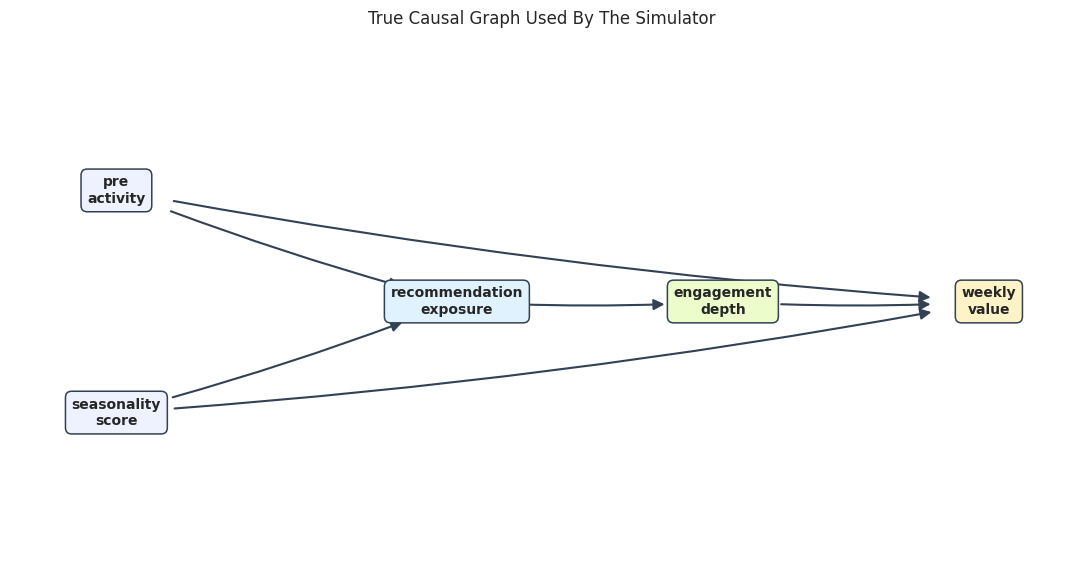

In [7]:
def draw_directed_graph(edges, positions, title, path, node_colors=None):
    node_colors = node_colors or {}
    nodes = list(dict.fromkeys([node for edge in edges for node in edge]))

    fig, ax = plt.subplots(figsize=(11, 5.8))
    ax.set_axis_off()

    for left, right in edges:
        start = positions[left]
        end = positions[right]
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color="#334155",
            shrinkA=42,
            shrinkB=42,
            connectionstyle="arc3,rad=0.03",
        )
        ax.add_patch(arrow)

    for node in nodes:
        x, y = positions[node]
        label = node.replace("_", "\n")
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=node_colors.get(node, "#e0f2fe"),
                edgecolor="#334155",
                linewidth=1.1,
            ),
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title, pad=18)
    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

node_colors = {
    "pre_activity": "#eef2ff",
    "seasonality_score": "#eef2ff",
    "recommendation_exposure": "#e0f2fe",
    "engagement_depth": "#ecfccb",
    "weekly_value": "#fef3c7",
}

draw_directed_graph(
    TRUE_EDGES,
    TRUE_POSITIONS,
    "True Causal Graph Used By The Simulator",
    FIGURE_DIR / "09_true_causal_graph.png",
    node_colors=node_colors,
)

The graph shows why `pre_activity` and `seasonality_score` are confounders for the total exposure effect. They affect exposure and the final outcome.

## Marginal Correlation Is Not A Causal Graph

A common first step is to inspect correlations. Correlations are useful for finding dependence, but they cannot distinguish direct effects from indirect paths or common causes.

,pre_activity,seasonality_score,recommendation_exposure,engagement_depth,weekly_value
pre_activity,1.0000,-0.0019,0.5933,0.5126,0.6138
seasonality_score,-0.0019,1.0000,0.4197,0.3648,0.4597
recommendation_exposure,0.5933,0.4197,1.0000,0.8641,0.8634
engagement_depth,0.5126,0.3648,0.8641,1.0000,0.9355
weekly_value,0.6138,0.4597,0.8634,0.9355,1.0000


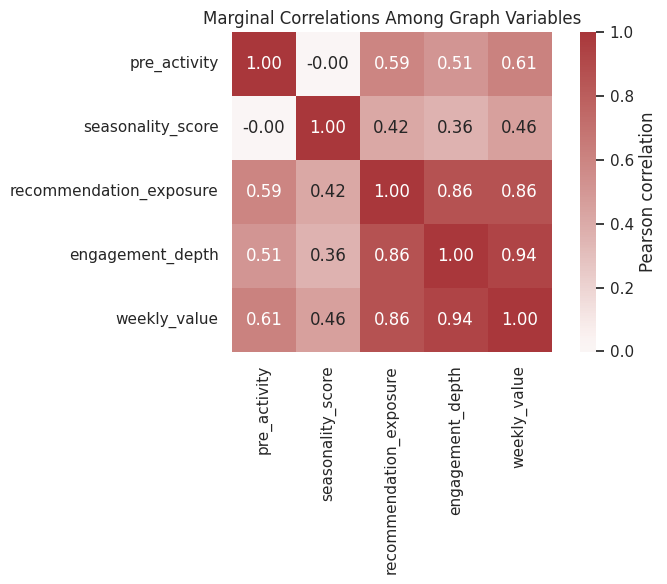

In [8]:
core_graph_df = graph_df[NODE_ORDER]
correlation_matrix = core_graph_df.corr()

correlation_matrix.to_csv(TABLE_DIR / "09_correlation_matrix.csv")
display(correlation_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Marginal Correlations Among Graph Variables")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_marginal_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

Many variables are correlated because the graph has mediated paths and common causes. A correlation heatmap can suggest candidate relationships, but it will usually overstate the number of direct causal edges.

## Naive Correlation-Based Candidate Edges

To make that limitation concrete, we build a naive candidate graph: if two variables have an absolute correlation above a threshold, we draw an edge from the earlier variable to the later variable according to the known time order.

This is not a recommended causal-discovery algorithm. It is a teaching baseline that shows why marginal dependence is not enough.

In [9]:
def correlation_candidate_edges(data, ordered_nodes, threshold=0.25):
    corr = data[ordered_nodes].corr()
    edges = []
    rows = []
    for i, source in enumerate(ordered_nodes):
        for target in ordered_nodes[i + 1 :]:
            value = corr.loc[source, target]
            keep = abs(value) >= threshold
            rows.append(
                {
                    "source": source,
                    "target": target,
                    "correlation": value,
                    "absolute_correlation": abs(value),
                    "selected_as_edge": keep,
                }
            )
            if keep:
                edges.append((source, target))
    return edges, pd.DataFrame(rows)

correlation_edges, correlation_edge_scores = correlation_candidate_edges(core_graph_df, NODE_ORDER, threshold=0.25)

correlation_edge_scores.to_csv(TABLE_DIR / "09_correlation_candidate_edge_scores.csv", index=False)
display(correlation_edge_scores.sort_values("absolute_correlation", ascending=False))
print("Correlation candidate edges:")
print(correlation_edges)

,source,target,correlation,absolute_correlation,selected_as_edge
9,engagement_depth,weekly_value,0.9355,0.9355,True
7,recommendation_exposure,engagement_depth,0.8641,0.8641,True
8,recommendation_exposure,weekly_value,0.8634,0.8634,True
3,pre_activity,weekly_value,0.6138,0.6138,True
1,pre_activity,recommendation_exposure,0.5933,0.5933,True
2,pre_activity,engagement_depth,0.5126,0.5126,True
6,seasonality_score,weekly_value,0.4597,0.4597,True
4,seasonality_score,recommendation_exposure,0.4197,0.4197,True
5,seasonality_score,engagement_depth,0.3648,0.3648,True
0,pre_activity,seasonality_score,-0.0019,0.0019,False


Correlation candidate edges:
[('pre_activity', 'recommendation_exposure'), ('pre_activity', 'engagement_depth'), ('pre_activity', 'weekly_value'), ('seasonality_score', 'recommendation_exposure'), ('seasonality_score', 'engagement_depth'), ('seasonality_score', 'weekly_value'), ('recommendation_exposure', 'engagement_depth'), ('recommendation_exposure', 'weekly_value'), ('engagement_depth', 'weekly_value')]


The correlation graph usually includes extra edges. For example, `recommendation_exposure` and `weekly_value` are correlated even though the true direct path goes through `engagement_depth`.

## Draw The Naive Correlation Graph

The visual below shows what happens when marginal correlations are treated as direct edges. It is dense because it confuses indirect association with direct causal structure.

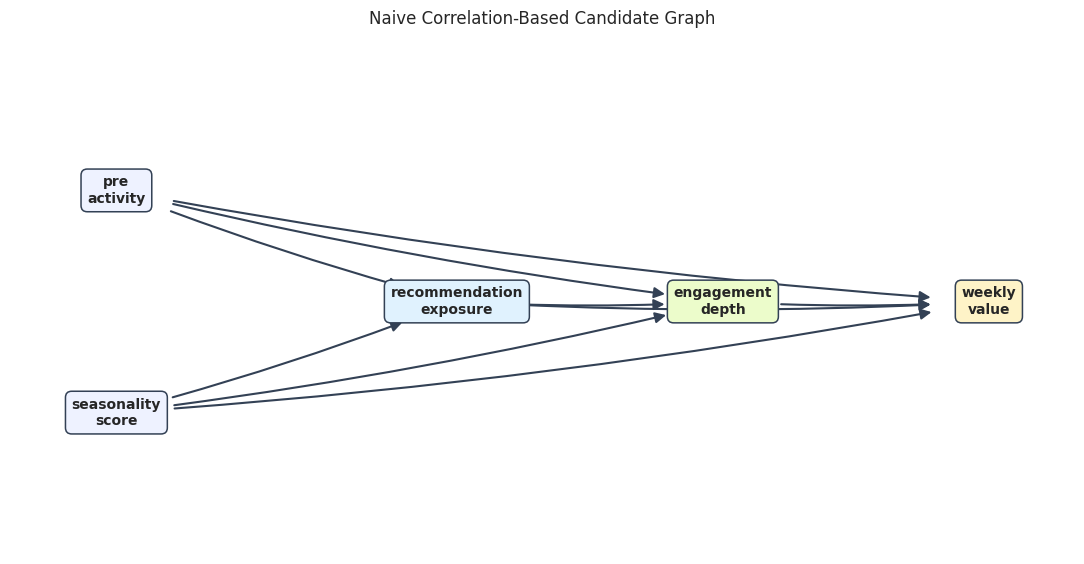

In [10]:
draw_directed_graph(
    correlation_edges,
    TRUE_POSITIONS,
    "Naive Correlation-Based Candidate Graph",
    FIGURE_DIR / "09_naive_correlation_candidate_graph.png",
    node_colors=node_colors,
)

This graph is useful as a warning. It is not useless, but it needs pruning by timing, conditional checks, and domain assumptions.

## Constraint-Assisted Discovery With Time Ordering

Now we use a more disciplined candidate-building approach. We assume a time order:

1. source variables: `pre_activity`, `seasonality_score`,
2. exposure: `recommendation_exposure`,
3. mediator: `engagement_depth`,
4. outcome: `weekly_value`.

For each target variable, we regress it on all earlier variables and keep edges with small p-values. This is still not a complete causal-discovery algorithm, but it is a transparent way to combine data with time-order constraints.

In [11]:
DISCOVERY_TIERS = {
    "pre_activity": 0,
    "seasonality_score": 0,
    "recommendation_exposure": 1,
    "engagement_depth": 2,
    "weekly_value": 3,
}


def tiered_regression_candidate_edges(data, tiers, alpha=0.001):
    edges = []
    rows = []
    ordered_nodes = sorted(tiers, key=lambda node: (tiers[node], node))

    for target in ordered_nodes:
        candidate_parents = [node for node in ordered_nodes if tiers[node] < tiers[target]]
        if not candidate_parents:
            continue
        formula = target + " ~ " + " + ".join(candidate_parents)
        model = smf.ols(formula, data=data).fit()
        for parent in candidate_parents:
            coefficient = model.params[parent]
            p_value = model.pvalues[parent]
            selected = p_value < alpha
            rows.append(
                {
                    "target": target,
                    "candidate_parent": parent,
                    "coefficient": coefficient,
                    "p_value": p_value,
                    "selected_as_edge": selected,
                }
            )
            if selected:
                edges.append((parent, target))
    return edges, pd.DataFrame(rows)

tiered_edges, tiered_edge_scores = tiered_regression_candidate_edges(core_graph_df, DISCOVERY_TIERS, alpha=0.001)

tiered_edge_scores.to_csv(TABLE_DIR / "09_tiered_regression_edge_scores.csv", index=False)
display(tiered_edge_scores.sort_values(["target", "p_value"]))
print("Tiered regression candidate edges:")
print(tiered_edges)

,target,candidate_parent,coefficient,p_value,selected_as_edge
4,engagement_depth,recommendation_exposure,1.1959,0.0000,True
3,engagement_depth,seasonality_score,0.0058,0.7262,False
2,engagement_depth,pre_activity,0.0019,0.9191,False
0,recommendation_exposure,pre_activity,0.8677,0.0000,True
1,recommendation_exposure,seasonality_score,0.5972,0.0000,True
5,weekly_value,pre_activity,0.8689,0.0000,True
6,weekly_value,seasonality_score,0.6857,0.0000,True
8,weekly_value,engagement_depth,1.3995,0.0000,True
7,weekly_value,recommendation_exposure,0.0120,0.5896,False


Tiered regression candidate edges:
[('pre_activity', 'recommendation_exposure'), ('seasonality_score', 'recommendation_exposure'), ('recommendation_exposure', 'engagement_depth'), ('pre_activity', 'weekly_value'), ('seasonality_score', 'weekly_value'), ('engagement_depth', 'weekly_value')]


Conditioning on earlier variables removes several indirect associations. The resulting graph should be much closer to the data-generating graph than the naive correlation graph.

## Draw The Constraint-Assisted Candidate Graph

The next graph shows the edges retained by the tiered regression screen. This is the candidate graph we would take into a graph-review conversation.

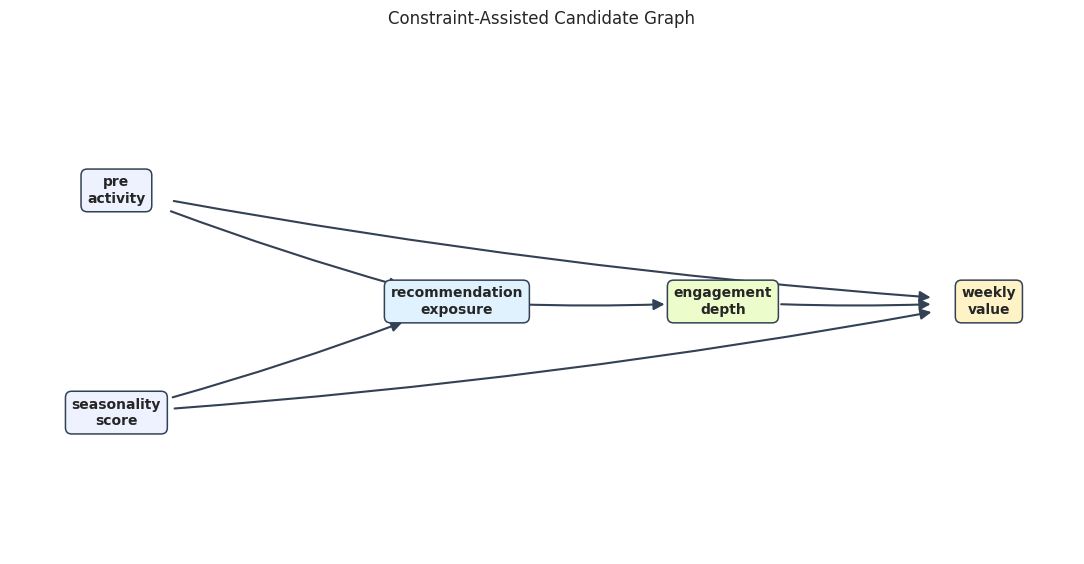

In [12]:
draw_directed_graph(
    tiered_edges,
    TRUE_POSITIONS,
    "Constraint-Assisted Candidate Graph",
    FIGURE_DIR / "09_constraint_assisted_candidate_graph.png",
    node_colors=node_colors,
)

The candidate graph is simpler than the correlation graph because it asks whether a relationship remains after accounting for earlier variables.

## Compare Candidate Graphs To The Known Truth

Since this is a simulation, we can score each candidate graph against the true edge list. In real data this table would not be possible, but it is excellent for learning what each discovery step is doing.

In [13]:
def compare_edges(candidate_edges, true_edges, label):
    candidate_set = set(candidate_edges)
    true_set = set(true_edges)
    rows = []
    for edge in sorted(candidate_set | true_set):
        rows.append(
            {
                "graph": label,
                "edge": f"{edge[0]} -> {edge[1]}",
                "in_candidate": edge in candidate_set,
                "in_truth": edge in true_set,
                "status": (
                    "true positive"
                    if edge in candidate_set and edge in true_set
                    else "false positive"
                    if edge in candidate_set and edge not in true_set
                    else "false negative"
                ),
            }
        )
    summary = {
        "graph": label,
        "true_positives": len(candidate_set & true_set),
        "false_positives": len(candidate_set - true_set),
        "false_negatives": len(true_set - candidate_set),
        "precision": len(candidate_set & true_set) / max(len(candidate_set), 1),
        "recall": len(candidate_set & true_set) / max(len(true_set), 1),
    }
    return pd.DataFrame(rows), summary

correlation_edge_comparison, correlation_summary = compare_edges(correlation_edges, TRUE_EDGES, "correlation screen")
tiered_edge_comparison, tiered_summary = compare_edges(tiered_edges, TRUE_EDGES, "tiered regression screen")

edge_comparison = pd.concat([correlation_edge_comparison, tiered_edge_comparison], ignore_index=True)
edge_summary = pd.DataFrame([correlation_summary, tiered_summary])

edge_comparison.to_csv(TABLE_DIR / "09_candidate_edge_comparison.csv", index=False)
edge_summary.to_csv(TABLE_DIR / "09_candidate_edge_summary.csv", index=False)

display(edge_summary)
display(edge_comparison)

,graph,true_positives,false_positives,false_negatives,precision,recall
0,correlation screen,6,3,0,0.6667,1.0000
1,tiered regression screen,6,0,0,1.0000,1.0000


,graph,edge,in_candidate,in_truth,status
0,correlation screen,engagement_depth -> weekly_value,True,True,true positive
1,correlation screen,pre_activity -> engagement_depth,True,False,false positive
2,correlation screen,pre_activity -> recommendation_exposure,True,True,true positive
3,correlation screen,pre_activity -> weekly_value,True,True,true positive
4,correlation screen,recommendation_exposure -> engagement_depth,True,True,true positive
5,correlation screen,recommendation_exposure -> weekly_value,True,False,false positive
6,correlation screen,seasonality_score -> engagement_depth,True,False,false positive
7,correlation screen,seasonality_score -> recommendation_exposure,True,True,true positive
8,correlation screen,seasonality_score -> weekly_value,True,True,true positive
9,tiered regression screen,engagement_depth -> weekly_value,True,True,true positive


The tiered regression screen should have fewer false positives. The broader lesson is that graph discovery improves when data checks are combined with timing and domain restrictions.

## Conditional Independence Checks By Hand

Graph refutation is based on implications such as “these two variables should be independent after conditioning on this set.” We will first compute a few partial correlations manually so the DoWhy graph refuter is easier to understand.

For continuous variables, a small partial correlation with a large p-value is consistent with conditional independence.

In [14]:
CONSTRAINTS_CORRECT_GRAPH = [
    (
        "recommendation_exposure",
        "weekly_value",
        ("engagement_depth", "pre_activity", "seasonality_score"),
        "No direct exposure-to-value edge after mediator and confounders are conditioned on.",
    ),
    (
        "pre_activity",
        "engagement_depth",
        ("recommendation_exposure",),
        "Pre-activity affects engagement through exposure in the true graph.",
    ),
    (
        "seasonality_score",
        "engagement_depth",
        ("recommendation_exposure",),
        "Seasonality affects engagement through exposure in the true graph.",
    ),
    (
        "pre_activity",
        "seasonality_score",
        tuple(),
        "The two source variables were generated independently.",
    ),
]

partial_corr_rows = []
for x, y, z, reason in CONSTRAINTS_CORRECT_GRAPH:
    stats = partial_corr(data=core_graph_df, x=x, y=y, z=list(z))
    partial_corr_rows.append(
        {
            "x": x,
            "y": y,
            "conditioning_set": ", ".join(z) if z else "none",
            "partial_correlation": stats["r"],
            "p_value": stats["p-val"],
            "consistent_with_independence_at_0_05": stats["p-val"] >= 0.05,
            "why_this_constraint_matters": reason,
        }
    )

partial_correlation_table = pd.DataFrame(partial_corr_rows)
partial_correlation_table.to_csv(TABLE_DIR / "09_manual_partial_correlation_checks.csv", index=False)
display(partial_correlation_table)

,x,y,conditioning_set,partial_correlation,p_value,consistent_with_independence_at_0_05,why_this_constraint_matters
0,recommendation_exposure,weekly_value,"engagement_depth, pre_activity, seasonality_score",0.0076,0.5896,True,No direct exposure-to-value edge after mediato...
1,pre_activity,engagement_depth,recommendation_exposure,-0.0003,0.9841,True,Pre-activity affects engagement through exposu...
2,seasonality_score,engagement_depth,recommendation_exposure,0.0047,0.7370,True,Seasonality affects engagement through exposur...
3,pre_activity,seasonality_score,none,-0.0019,0.8942,True,The two source variables were generated indepe...


These checks are consistent with the true graph: the tested conditional independencies have small partial correlations and non-small p-values.

## Refute The Correct Graph With DoWhy

Now we pass the same conditional-independence constraints to DoWhy's graph refuter. The refuter counts how many constraints are satisfied by the data.

In [15]:
def edges_to_dot(edges, graph_name="causal_graph"):
    edge_lines = [f"    {left} -> {right};" for left, right in edges]
    return "digraph " + graph_name + " {\n" + "\n".join(edge_lines) + "\n}"

true_graph_dot = edges_to_dot(TRUE_EDGES, graph_name="true_graph")

graph_model_correct = CausalModel(
    data=core_graph_df,
    treatment="recommendation_exposure",
    outcome="weekly_value",
    graph=true_graph_dot,
)

correct_graph_constraints = [(x, y, z) for x, y, z, _ in CONSTRAINTS_CORRECT_GRAPH]
correct_graph_refutation = graph_model_correct.refute_graph(independence_constraints=correct_graph_constraints)

print(correct_graph_refutation)

Method name for discrete data:conditional_mutual_information
Method name for continuous data:partial_correlation
Number of conditional independencies entailed by model:4
Number of independences satisfied by data:4
Test passed:True



The correct graph should pass these hand-picked constraints. Passing does not prove the graph is true; it only says these particular graph implications were not contradicted by the data.

## Build A Plausible But Wrong Graph

Now we create a graph that omits the edge from `pre_activity` to `weekly_value`. This is a common applied mistake: a variable is known to affect treatment, but its direct relationship to the outcome is under-modeled.

If that edge is missing, the graph implies a false conditional independence: `pre_activity` should be independent of `weekly_value` after conditioning on exposure, engagement, and seasonality. The data should reject that implication.

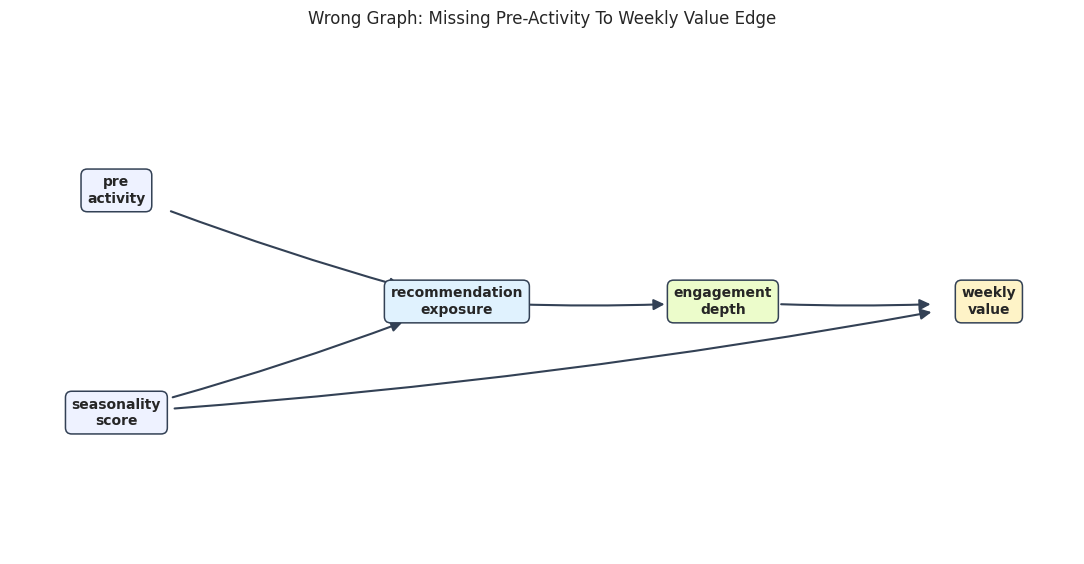

In [16]:
WRONG_EDGES_MISSING_PRE_TO_VALUE = [
    ("pre_activity", "recommendation_exposure"),
    ("seasonality_score", "recommendation_exposure"),
    ("recommendation_exposure", "engagement_depth"),
    ("engagement_depth", "weekly_value"),
    ("seasonality_score", "weekly_value"),
]

wrong_graph_positions = TRUE_POSITIONS.copy()

draw_directed_graph(
    WRONG_EDGES_MISSING_PRE_TO_VALUE,
    wrong_graph_positions,
    "Wrong Graph: Missing Pre-Activity To Weekly Value Edge",
    FIGURE_DIR / "09_wrong_graph_missing_pre_to_value.png",
    node_colors=node_colors,
)

The wrong graph still looks plausible at a glance. That is why graph refutation checks are useful: they can turn a visual assumption into a testable conditional-independence claim.

## Refute The Wrong Graph With A Targeted Constraint

This test checks the false implication introduced by omitting the `pre_activity -> weekly_value` edge.

In [17]:
wrong_graph_constraint = [
    (
        "pre_activity",
        "weekly_value",
        ("recommendation_exposure", "engagement_depth", "seasonality_score"),
    )
]

wrong_constraint_stats = partial_corr(
    data=core_graph_df,
    x="pre_activity",
    y="weekly_value",
    z=["recommendation_exposure", "engagement_depth", "seasonality_score"],
)
wrong_constraint_table = pd.DataFrame(
    [
        {
            "x": "pre_activity",
            "y": "weekly_value",
            "conditioning_set": "recommendation_exposure, engagement_depth, seasonality_score",
            "partial_correlation": wrong_constraint_stats["r"],
            "p_value": wrong_constraint_stats["p-val"],
            "consistent_with_independence_at_0_05": wrong_constraint_stats["p-val"] >= 0.05,
        }
    ]
)

wrong_graph_model = CausalModel(
    data=core_graph_df,
    treatment="recommendation_exposure",
    outcome="weekly_value",
    graph=edges_to_dot(WRONG_EDGES_MISSING_PRE_TO_VALUE, graph_name="wrong_graph"),
)
wrong_graph_refutation = wrong_graph_model.refute_graph(independence_constraints=wrong_graph_constraint)

wrong_constraint_table.to_csv(TABLE_DIR / "09_wrong_graph_constraint_check.csv", index=False)
display(wrong_constraint_table)
print(wrong_graph_refutation)

,x,y,conditioning_set,partial_correlation,p_value,consistent_with_independence_at_0_05
0,pre_activity,weekly_value,"recommendation_exposure, engagement_depth, sea...",0.5424,0.0000,False


Method name for discrete data:conditional_mutual_information
Method name for continuous data:partial_correlation
Number of conditional independencies entailed by model:1
Number of independences satisfied by data:0
Test passed:False



The wrong graph should fail because `pre_activity` remains strongly related to `weekly_value` even after conditioning on the variables that the wrong graph claims are sufficient.

## Compare Graph Refutation Results

This compact table compares the correct graph and the wrong graph. The wrong graph fails because it entails a conditional independence that the data do not support.

In [18]:
graph_refutation_summary = pd.DataFrame(
    [
        {
            "graph": "true graph",
            "constraints_tested": correct_graph_refutation.number_of_constraints_model,
            "constraints_satisfied": correct_graph_refutation.number_of_constraints_satisfied,
            "passed": correct_graph_refutation.refutation_result,
        },
        {
            "graph": "wrong graph missing pre_activity -> weekly_value",
            "constraints_tested": wrong_graph_refutation.number_of_constraints_model,
            "constraints_satisfied": wrong_graph_refutation.number_of_constraints_satisfied,
            "passed": wrong_graph_refutation.refutation_result,
        },
    ]
)

graph_refutation_summary.to_csv(TABLE_DIR / "09_graph_refutation_summary.csv", index=False)
display(graph_refutation_summary)

,graph,constraints_tested,constraints_satisfied,passed
0,true graph,4,4,True
1,wrong graph missing pre_activity -> weekly_value,1,0,False


Graph refutation is most useful when it is targeted. A graph can imply many constraints, but the best checks are often the ones tied to the causal risks that would change the estimate.

## Graph Choice Changes The Causal Estimate

The previous check showed that the wrong graph is inconsistent with the data. Now we show why that matters: DoWhy uses the graph to decide the adjustment set. If the graph omits a confounder-to-outcome edge, DoWhy may omit that variable from adjustment and produce a biased estimate.

In [19]:
correct_estimand = graph_model_correct.identify_effect(proceed_when_unidentifiable=True)
correct_estimate = graph_model_correct.estimate_effect(
    correct_estimand,
    method_name="backdoor.linear_regression",
)

wrong_estimand = wrong_graph_model.identify_effect(proceed_when_unidentifiable=True)
wrong_estimate = wrong_graph_model.estimate_effect(
    wrong_estimand,
    method_name="backdoor.linear_regression",
)

estimate_by_graph = pd.DataFrame(
    [
        {
            "graph": "true graph",
            "adjustment_set": ", ".join(correct_estimand.get_adjustment_set()),
            "estimate": correct_estimate.value,
            "target": true_total_effect,
        },
        {
            "graph": "wrong graph missing pre_activity -> weekly_value",
            "adjustment_set": ", ".join(wrong_estimand.get_adjustment_set()),
            "estimate": wrong_estimate.value,
            "target": true_total_effect,
        },
    ]
)
estimate_by_graph["error_vs_target"] = estimate_by_graph["estimate"] - estimate_by_graph["target"]

estimate_by_graph.to_csv(TABLE_DIR / "09_effect_estimates_by_graph.csv", index=False)
display(estimate_by_graph)

,graph,adjustment_set,estimate,target,error_vs_target
0,true graph,"seasonality_score, pre_activity",1.6855,1.6800,0.0055
1,wrong graph missing pre_activity -> weekly_value,seasonality_score,2.1159,1.6800,0.4359


The wrong graph gives a biased estimate because it fails to adjust for `pre_activity` as a confounder. This is the practical reason graph assumptions matter: graph mistakes flow directly into estimation choices.

## Plot Estimates From Different Graphs

The dashed line is the true total effect from the simulator. The correct graph estimate should land near the dashed line, while the wrong graph estimate is pulled upward by omitted confounding.

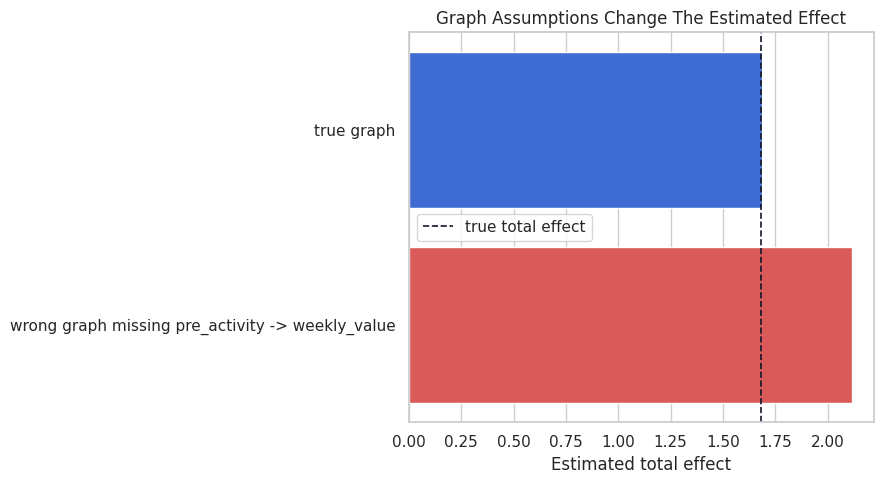

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=estimate_by_graph,
    x="estimate",
    y="graph",
    hue="graph",
    dodge=False,
    legend=False,
    palette=["#2563eb", "#ef4444"],
    ax=ax,
)
ax.axvline(true_total_effect, color="#111827", linestyle="--", linewidth=1.2, label="true total effect")
ax.set_title("Graph Assumptions Change The Estimated Effect")
ax.set_xlabel("Estimated total effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "09_effect_estimates_by_graph.png", dpi=160, bbox_inches="tight")
plt.show()

This plot ties graph refutation back to causal estimation. The issue is not only whether the graph is aesthetically plausible; it changes the numerical answer.

## Overcomplete Graphs Can Be Hard To Reject

Graph refutation can often reject graphs that imply false independencies. It is less able to reject graphs that add extra edges. Extra edges remove conditional-independence claims, so there may be fewer testable implications.

The graph below adds a direct edge from exposure to value even though the simulator has no direct edge. This overcomplete graph may pass many checks because it makes fewer independence claims.

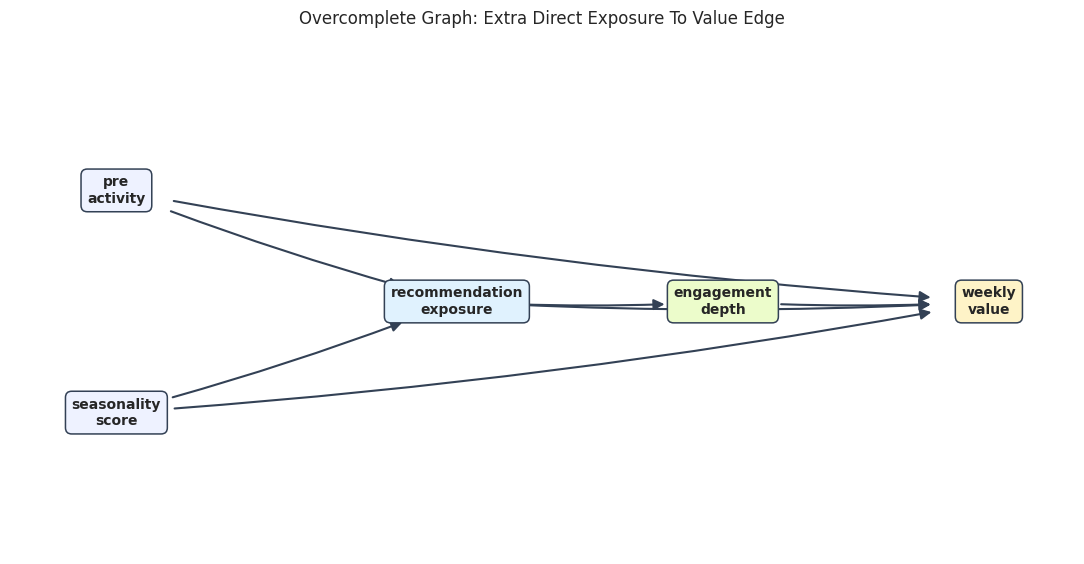

In [21]:
OVERCOMPLETE_EDGES = TRUE_EDGES + [("recommendation_exposure", "weekly_value")]

draw_directed_graph(
    OVERCOMPLETE_EDGES,
    TRUE_POSITIONS,
    "Overcomplete Graph: Extra Direct Exposure To Value Edge",
    FIGURE_DIR / "09_overcomplete_graph_extra_edge.png",
    node_colors=node_colors,
)

The extra edge makes the graph more flexible but less informative. This is why graph building should value parsimony and domain logic, not only refutation pass/fail results.

## A Small Overcomplete-Graph Check

The overcomplete graph still implies that the two source variables are independent, so it can pass that weak check. But passing one weak check does not establish that the extra direct edge is real.

In [22]:
overcomplete_model = CausalModel(
    data=core_graph_df,
    treatment="recommendation_exposure",
    outcome="weekly_value",
    graph=edges_to_dot(OVERCOMPLETE_EDGES, graph_name="overcomplete_graph"),
)
overcomplete_refutation = overcomplete_model.refute_graph(
    independence_constraints=[("pre_activity", "seasonality_score", tuple())]
)

overcomplete_summary = pd.DataFrame(
    [
        {
            "graph": "overcomplete graph with extra direct edge",
            "constraints_tested": overcomplete_refutation.number_of_constraints_model,
            "constraints_satisfied": overcomplete_refutation.number_of_constraints_satisfied,
            "passed": overcomplete_refutation.refutation_result,
            "main lesson": "Passing a weak implication does not prove every edge is necessary.",
        }
    ]
)

overcomplete_summary.to_csv(TABLE_DIR / "09_overcomplete_graph_refutation.csv", index=False)
display(overcomplete_summary)
print(overcomplete_refutation)

,graph,constraints_tested,constraints_satisfied,passed,main lesson
0,overcomplete graph with extra direct edge,1,1,True,Passing a weak implication does not prove ever...


Method name for discrete data:conditional_mutual_information
Method name for continuous data:partial_correlation
Number of conditional independencies entailed by model:1
Number of independences satisfied by data:1
Test passed:True



This is a subtle but important lesson: graph refutation is better at finding contradictions than proving completeness. Extra edges can make a graph harder to falsify.

## Discovery Workflow Summary

Now we collect the main outputs into one table: the naive correlation graph, the constraint-assisted graph, the correct graph refutation, and the wrong graph refutation.

In [23]:
workflow_summary = pd.DataFrame(
    [
        {
            "workflow piece": "naive correlation screen",
            "result": f"{len(correlation_edges)} candidate edges",
            "lesson": "marginal dependence produces false positive direct edges",
        },
        {
            "workflow piece": "tiered regression screen",
            "result": f"{len(tiered_edges)} candidate edges",
            "lesson": "time ordering plus conditioning gives a cleaner candidate graph",
        },
        {
            "workflow piece": "true graph refutation",
            "result": f"{correct_graph_refutation.number_of_constraints_satisfied}/{correct_graph_refutation.number_of_constraints_model} constraints satisfied",
            "lesson": "targeted graph implications are consistent with the data",
        },
        {
            "workflow piece": "wrong graph refutation",
            "result": f"{wrong_graph_refutation.number_of_constraints_satisfied}/{wrong_graph_refutation.number_of_constraints_model} constraints satisfied",
            "lesson": "missing an outcome edge creates a false conditional-independence claim",
        },
        {
            "workflow piece": "effect estimate comparison",
            "result": f"correct {correct_estimate.value:.3f}; wrong {wrong_estimate.value:.3f}; target {true_total_effect:.3f}",
            "lesson": "graph errors can become estimation errors",
        },
    ]
)

workflow_summary.to_csv(TABLE_DIR / "09_workflow_summary.csv", index=False)
display(workflow_summary)

,workflow piece,result,lesson
0,naive correlation screen,9 candidate edges,marginal dependence produces false positive di...
1,tiered regression screen,6 candidate edges,time ordering plus conditioning gives a cleane...
2,true graph refutation,4/4 constraints satisfied,targeted graph implications are consistent wit...
3,wrong graph refutation,0/1 constraints satisfied,missing an outcome edge creates a false condit...
4,effect estimate comparison,correct 1.686; wrong 2.116; target 1.680,graph errors can become estimation errors


The workflow moves from exploratory discovery to graph stress testing to effect estimation. That order is deliberate: we should challenge graph assumptions before presenting a causal effect as credible.

## Practical Checklist For Graph Discovery And Refutation

Use this checklist when applying graph discovery ideas to real data:

- Start with measurement timing and domain constraints before looking at algorithms.
- Use marginal dependence as a clue, not as a direct edge list.
- Prefer candidate graphs that are explainable and time-respecting.
- Translate key graph assumptions into conditional-independence checks.
- Test the graph implications that would change the adjustment set or estimand.
- Remember that passing graph checks does not prove the graph; it only removes some contradictions.
- Be especially cautious about hidden confounders and extra edges that reduce testable implications.

## Practice Prompts

Try these extensions after running the notebook:

1. Add a direct edge from `recommendation_exposure` to `weekly_value` in the simulator. Which partial-correlation check changes?
2. Make `pre_activity` and `seasonality_score` correlated. Which source-variable independence check fails?
3. Lower the correlation threshold in the naive graph screen. How many false positives appear?
4. Remove the time-order constraint from the tiered regression screen. What edge directions become ambiguous?
5. Write a short graph-review memo explaining which assumptions are testable and which require domain judgment.

## What Comes Next

The next tutorial moves from classic DoWhy causal models into graphical causal models. Instead of only identifying and estimating a treatment effect, we will model causal mechanisms attached to graph nodes and use them for richer diagnostic and simulation tasks.